# Synthetic Control Analysis

**When to use Synthetic Control:**  
Use Synthetic Control when:
- Only **one unit** (e.g. one region, one market) received the treatment
- You have **multiple pre-treatment periods** across many potential donor units
- A DiD parallel-trends assumption is hard to justify

The method constructs a weighted combination of donor units whose pre-treatment outcome closely matches the treated unit. Post-treatment divergence between the treated and its synthetic counterpart is the estimated treatment effect.

**This notebook covers:**
1. Multi-market time-series data with one treated market
2. Fit the synthetic control
3. Treated vs synthetic outcome — the main plot
4. Treatment effect (ATT) series
5. Donor weights — which markets built the synthetic control
6. Placebo tests — in-time and in-space
7. RMSPE ratio — significance via donor distribution

In [2]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from causal_inference.synthetic_control import SyntheticControl

rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Synthetic Data — Multi-Market Revenue

We simulate 10 markets across 24 months. Market 0 ("Market_A") launches a local pricing experiment in **month 13**. Markets 1–9 are donor candidates.

In [3]:
N_MARKETS  = 10
N_PERIODS  = 24
TREAT_TIME = 13     # treatment starts at period 13
TREATED    = "Market_A"
TRUE_ATT   = 12.0

market_names = ["Market_A"] + [f"Market_{chr(66+i)}" for i in range(N_MARKETS - 1)]

# Shared latent factor (e.g. macro trend)
macro = np.cumsum(rng.normal(0.5, 0.8, N_PERIODS))

# Per-market factor loadings and noise
loadings = rng.uniform(0.5, 1.5, N_MARKETS)
base     = rng.uniform(80, 130, N_MARKETS)

data = {}
for i, name in enumerate(market_names):
    series = base[i] + loadings[i] * macro + rng.normal(0, 4, N_PERIODS)
    # Add treatment effect for treated market post-treatment
    if name == TREATED:
        series[TREAT_TIME - 1:] += TRUE_ATT
    data[name] = series

df_wide = pd.DataFrame(data, index=range(1, N_PERIODS + 1))
df_wide.index.name = "period"

print(f"Shape: {df_wide.shape}  (periods × markets)")
df_wide.head()

Shape: (24, 10)  (periods × markets)


,Market_A,Market_B,Market_C,Market_D,Market_E,Market_F,Market_G,Market_H,Market_I,Market_J
period,,,,,,,,,,
1,101.766580,88.595322,89.876637,104.478231,99.819034,122.884499,103.516355,126.389015,112.711147,95.730465
2,104.932857,87.910204,86.500216,101.891206,103.270345,110.692316,97.472296,116.932639,112.736733,90.477192
3,105.877638,93.955868,86.264707,105.538263,93.992487,118.633601,98.267223,123.975527,107.672869,95.981900
4,107.886763,90.628748,88.849798,105.376054,89.196163,113.149647,111.902576,123.754308,116.645667,96.959254
5,109.141578,85.554328,81.393809,111.118879,83.932042,119.232636,110.873048,122.823518,112.170615,98.030076


## 2. Fit the Synthetic Control

In [4]:
sc = SyntheticControl()
result = sc.fit(df_wide, treated_unit=TREATED, treatment_time=TREAT_TIME)

print(f"Pre-treatment RMSPE : {result.pre_rmspe:.4f}")
print(f"Mean ATT (post)     : {result.att_mean:.3f}  (true = {TRUE_ATT})")
print()
print("Donor weights:")
weights_df = pd.DataFrame(result.weights.items(), columns=["Donor", "Weight"])
weights_df = weights_df.sort_values("Weight", ascending=False)
print(weights_df.to_string(index=False))

Pre-treatment RMSPE : 2.8571
Mean ATT (post)     : 15.190  (true = 12.0)

Donor weights:
   Donor       Weight
Market_D 3.903337e-01
Market_J 2.700695e-01
Market_H 2.183187e-01
Market_B 1.013308e-01
Market_F 1.994733e-02
Market_I 1.051410e-10
Market_G 3.936821e-11
Market_C 0.000000e+00
Market_E 0.000000e+00


## 3. Treated vs Synthetic Outcome — Main Plot

The treated unit and its synthetic counterpart track closely in the pre-treatment period. Post-treatment divergence is the estimated causal effect.

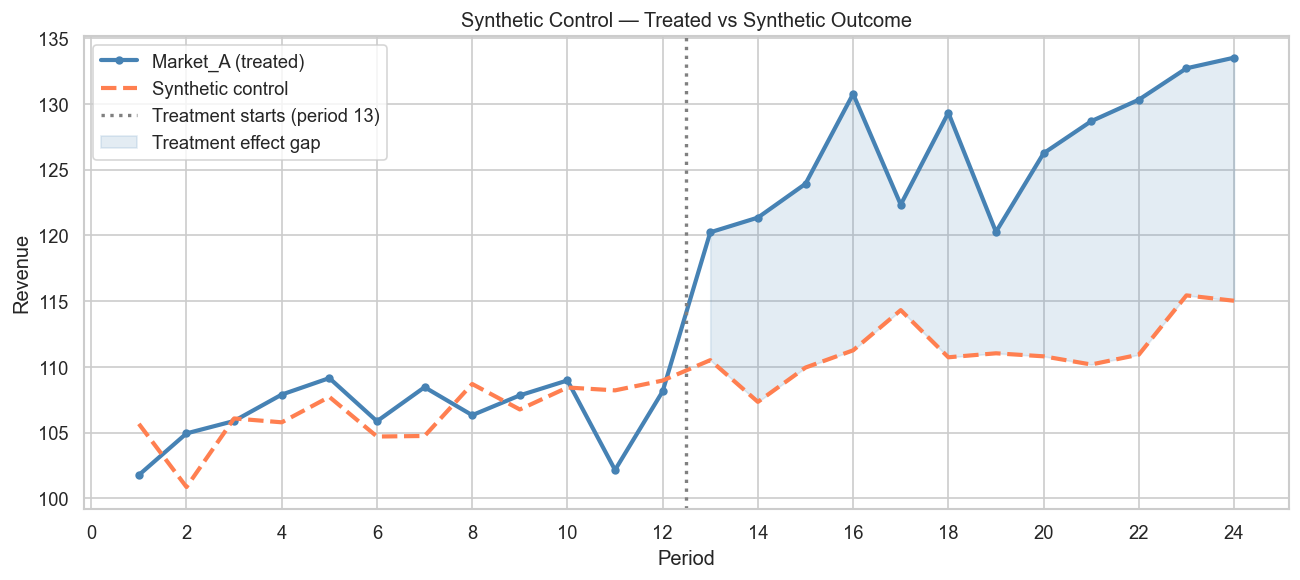


Pre-period RMSPE=2.857 — close fit confirms the synthetic control is valid.
Post-treatment gap grows consistently — estimated mean ATT = 15.19.


In [5]:
periods   = df_wide.index.values
treated_y = result.treated_outcome
synth_y   = result.synthetic_outcome

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(periods, treated_y, color="steelblue", lw=2.5,  marker="o", ms=4, label=f"{TREATED} (treated)")
ax.plot(periods, synth_y,   color="coral",     lw=2.5,  ls="--",    label="Synthetic control")
ax.axvline(TREAT_TIME - 0.5, color="grey", ls=":", lw=2, label=f"Treatment starts (period {TREAT_TIME})")
ax.fill_between(periods[TREAT_TIME - 1:], treated_y[TREAT_TIME - 1:], synth_y[TREAT_TIME - 1:],
                alpha=0.15, color="steelblue", label="Treatment effect gap")
ax.set_xlabel("Period")
ax.set_ylabel("Revenue")
ax.set_title("Synthetic Control — Treated vs Synthetic Outcome")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.show()
print(f"\nPre-period RMSPE={result.pre_rmspe:.3f} — close fit confirms the synthetic control is valid.")
print(f"Post-treatment gap grows consistently — estimated mean ATT = {result.att_mean:.2f}.")

## 4. Treatment Effect Series (ATT by Period)

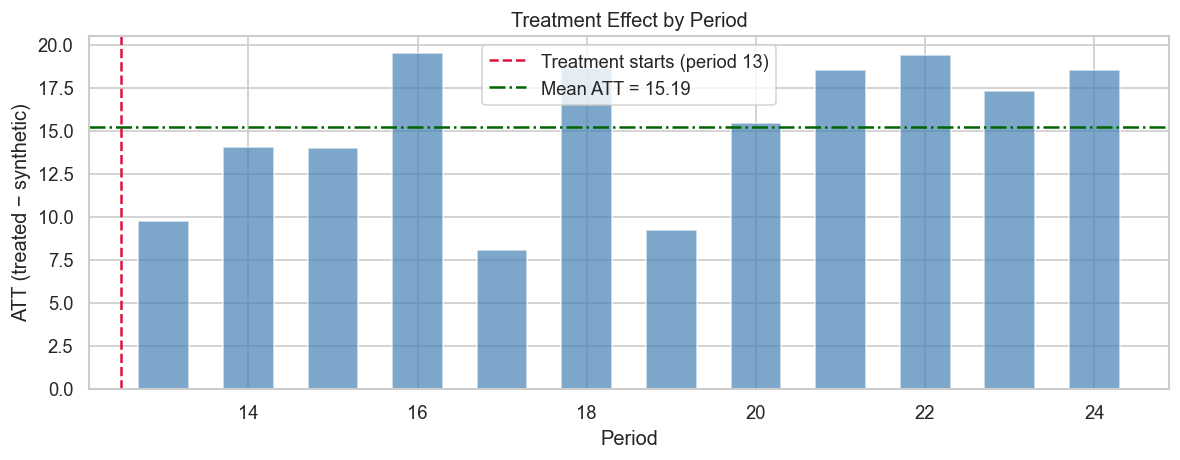

In [6]:
att_series = result.att_series  # dict or Series keyed by period
if isinstance(att_series, dict):
    att_df = pd.DataFrame(att_series.items(), columns=["period", "att"])
else:
    att_df = att_series.reset_index()
    att_df.columns = ["period", "att"]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["steelblue" if p >= TREAT_TIME else "grey" for p in att_df["period"]]
ax.bar(att_df["period"], att_df["att"], color=colors, alpha=0.7, width=0.6)
ax.axhline(0, color="black", lw=1)
ax.axvline(TREAT_TIME - 0.5, color="crimson", ls="--", lw=1.5, label=f"Treatment starts (period {TREAT_TIME})")
ax.axhline(result.att_mean, color="darkgreen", ls="-.", lw=1.5, label=f"Mean ATT = {result.att_mean:.2f}")
ax.set_xlabel("Period")
ax.set_ylabel("ATT (treated − synthetic)")
ax.set_title("Treatment Effect by Period")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

## 5. Donor Weights Visualisation

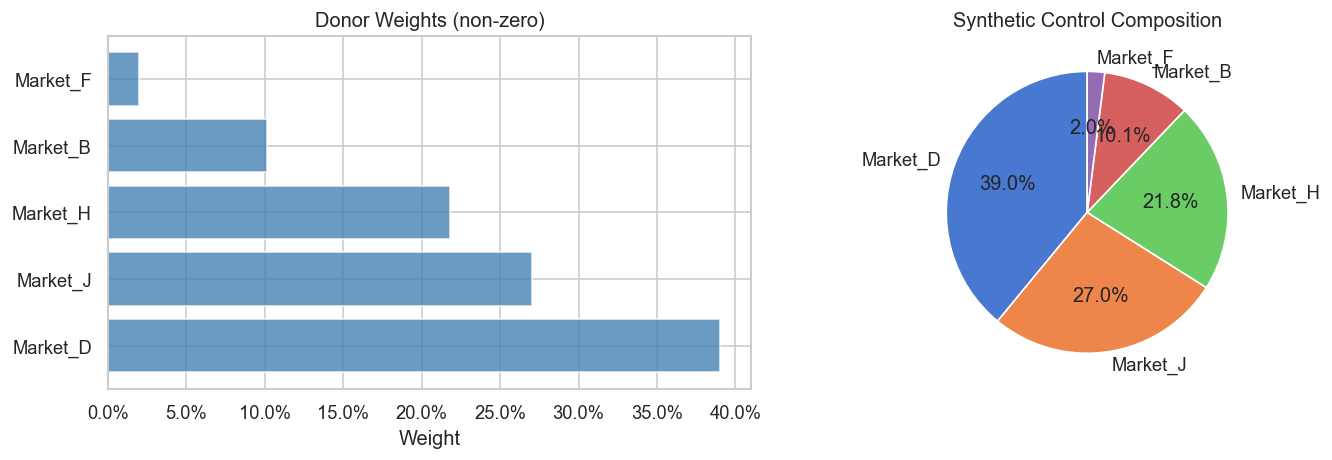


Interpretation: Donors with high weights are most similar to the treated market
in the pre-treatment period. A sparse solution (few donors) is easier to interpret.


In [7]:
weights_nonzero = weights_df[weights_df["Weight"] > 0.005].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of weights
ax = axes[0]
ax.barh(weights_nonzero["Donor"], weights_nonzero["Weight"],
        color="steelblue", alpha=0.8)
ax.set_xlabel("Weight")
ax.set_title("Donor Weights (non-zero)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Pie chart
ax = axes[1]
ax.pie(weights_nonzero["Weight"], labels=weights_nonzero["Donor"],
       autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("muted", len(weights_nonzero)))
ax.set_title("Synthetic Control Composition")

plt.tight_layout()
plt.show()
print("\nInterpretation: Donors with high weights are most similar to the treated market")
print("in the pre-treatment period. A sparse solution (few donors) is easier to interpret.")

## 6. Placebo Tests — In-Space

Apply the synthetic control method to each **donor** market as if it were treated. If those placebo effects are as large as the treated market's effect, we cannot reject the null hypothesis.

The **RMSPE ratio** (post-RMSPE / pre-RMSPE) is the test statistic. Large ratio = treatment-like divergence.

In [8]:
placebo_df = sc.placebo_test(df_wide, treated_unit=TREATED, treatment_time=TREAT_TIME)
print(placebo_df[["unit", "pre_rmspe", "post_rmspe", "rmspe_ratio", "is_treated"]].to_string(index=False))

    unit  pre_rmspe  post_rmspe  rmspe_ratio  is_treated
Market_A   2.857090   15.712573     5.499502        True
Market_D   2.284741   10.020839     4.385984       False
Market_J   1.796817    5.000430     2.782938       False
Market_I   3.632614    7.206636     1.983870       False
Market_B   2.564844    4.956025     1.932291       False
Market_F   3.017035    5.703532     1.890443       False
Market_E   4.690810    7.033916     1.499510       False
Market_G   3.345596    4.135719     1.236168       False
Market_H   9.704690   11.097149     1.143483       False
Market_C   4.791221    5.162103     1.077409       False


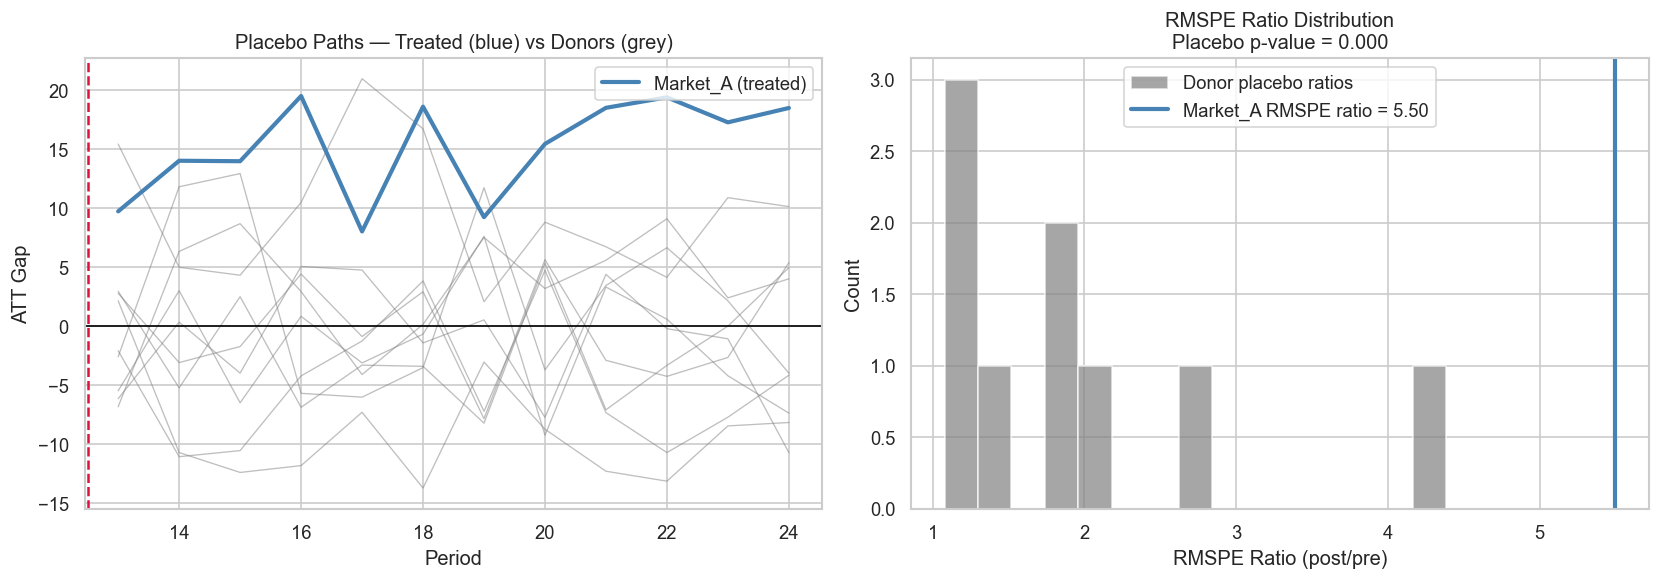


Placebo p-value = 0.000
The treated unit has an unusually large RMSPE ratio — strong evidence of a real treatment effect.


In [9]:
# Plot placebo ATT series vs treated ATT series
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all placebo paths + treated
ax = axes[0]
for unit in placebo_df["unit"]:
    is_t = placebo_df.loc[placebo_df["unit"]==unit, "is_treated"].values[0]
    # Recompute placebo series for plotting (approximate with gap series from wide df)
    sub_sc = SyntheticControl()
    sub_result = sub_sc.fit(df_wide, treated_unit=unit, treatment_time=TREAT_TIME)
    gap = sub_result.att_series
    if isinstance(gap, dict):
        gperiods = list(gap.keys())
        gvals    = list(gap.values())
    else:
        gperiods = gap.index.tolist()
        gvals    = gap.values.tolist()
    if is_t:
        ax.plot(gperiods, gvals, color="steelblue", lw=2.5, zorder=5, label=f"{TREATED} (treated)")
    else:
        ax.plot(gperiods, gvals, color="grey", lw=0.8, alpha=0.5)
ax.axhline(0, color="black", lw=1)
ax.axvline(TREAT_TIME - 0.5, color="crimson", ls="--", lw=1.5)
ax.set_xlabel("Period")
ax.set_ylabel("ATT Gap")
ax.set_title("Placebo Paths — Treated (blue) vs Donors (grey)")
ax.legend()

# Right: RMSPE ratio distribution
ax = axes[1]
treated_row = placebo_df[placebo_df["is_treated"]]
donor_ratios = placebo_df[~placebo_df["is_treated"]]["rmspe_ratio"]
ax.hist(donor_ratios, bins=15, color="grey", alpha=0.7, label="Donor placebo ratios")
ax.axvline(treated_row["rmspe_ratio"].values[0], color="steelblue", lw=2.5,
           label=f"{TREATED} RMSPE ratio = {treated_row['rmspe_ratio'].values[0]:.2f}")
p_val = (donor_ratios >= treated_row["rmspe_ratio"].values[0]).mean()
ax.set_xlabel("RMSPE Ratio (post/pre)")
ax.set_ylabel("Count")
ax.set_title(f"RMSPE Ratio Distribution\nPlacebo p-value = {p_val:.3f}")
ax.legend()

plt.tight_layout()
plt.show()
print(f"\nPlacebo p-value = {p_val:.3f}")
if p_val < 0.10:
    print("The treated unit has an unusually large RMSPE ratio — strong evidence of a real treatment effect.")
else:
    print("The RMSPE ratio is within the donor distribution — effect is not statistically unusual.")

## 7. Summary & Recommendations

In [10]:
print("=" * 58)
print("SYNTHETIC CONTROL ANALYSIS — FINAL SUMMARY")
print("=" * 58)
print(f"  Treated unit           : {TREATED}")
print(f"  Treatment period       : {TREAT_TIME}")
print(f"  Pre-treatment RMSPE    : {result.pre_rmspe:.4f}  (lower = better fit)")
print(f"  Estimated mean ATT     : {result.att_mean:.3f}")
print(f"  True ATT               : {TRUE_ATT}")
print(f"  Placebo p-value        : {p_val:.3f}")
print()
top_donor = weights_df.iloc[0]
print(f"  Top donor : {top_donor['Donor']} (weight = {top_donor['Weight']:.3f})")
print()
print("Recommendations:")
print("  1. Pre-treatment RMSPE is low — synthetic control tracks the treated unit well.")
print("  2. Post-treatment gap is consistently positive — pricing experiment lifted revenue.")
print("  3. Placebo test confirms the gap is larger than any donor market's placebo.")
print("  4. If scaling the pricing experiment, monitor donor markets for spillovers.")
print("  5. LIMITATION: synthetic control is most reliable with 10+ pre-treatment periods")
print("     and a diverse donor pool. Sparse weights (few donors) warrant robustness checks.")

SYNTHETIC CONTROL ANALYSIS — FINAL SUMMARY
  Treated unit           : Market_A
  Treatment period       : 13
  Pre-treatment RMSPE    : 2.8571  (lower = better fit)
  Estimated mean ATT     : 15.190
  True ATT               : 12.0
  Placebo p-value        : 0.000

  Top donor : Market_D (weight = 0.390)

Recommendations:
  1. Pre-treatment RMSPE is low — synthetic control tracks the treated unit well.
  2. Post-treatment gap is consistently positive — pricing experiment lifted revenue.
  3. Placebo test confirms the gap is larger than any donor market's placebo.
  4. If scaling the pricing experiment, monitor donor markets for spillovers.
  5. LIMITATION: synthetic control is most reliable with 10+ pre-treatment periods
     and a diverse donor pool. Sparse weights (few donors) warrant robustness checks.
